In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import glob, os
dataset_path = "/content/drive/MyDrive/rgb"
image_files = sorted(glob.glob(os.path.join(dataset_path, "*.png")))
print("Total images:", len(image_files))

Total images: 613


In [3]:
!pip install kornia kornia_moons -q

import torch
import kornia as K
import kornia.feature as KF
import cv2
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

device = 'cuda' if torch.cuda.is_available() else 'cpu'

disk = KF.DISK.from_pretrained('depth').to(device).eval()
lg_matcher = KF.LightGlueMatcher('disk').to(device).eval()

print("DISK + LightGlue loaded on", device)

Loaded LightGlue model
DISK + LightGlue loaded on cuda


In [4]:
results_disk = []

for i in range(len(image_files) - 1):
    img1_bgr = cv2.imread(image_files[i])
    img2_bgr = cv2.imread(image_files[i + 1])
    img1_rgb = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2RGB)
    img2_rgb = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2RGB)

    t1 = K.image_to_tensor(img1_rgb, False).float().to(device) / 255.0
    t2 = K.image_to_tensor(img2_rgb, False).float().to(device) / 255.0

    with torch.no_grad():
        feats1 = disk(t1, n=2048, window_size=5, score_threshold=0.0, pad_if_not_divisible=True)[0]
        feats2 = disk(t2, n=2048, window_size=5, score_threshold=0.0, pad_if_not_divisible=True)[0]
        kpts1, desc1 = feats1.keypoints, feats1.descriptors
        kpts2, desc2 = feats2.keypoints, feats2.descriptors
        dists, idxs = lg_matcher(desc1, desc2, KF.laf_from_center_scale_ori(kpts1[None]),
                                  KF.laf_from_center_scale_ori(kpts2[None]))

    num_matches = len(idxs)
    if num_matches < 4:
        results_disk.append((i, i + 1, num_matches, 0))
        continue

    mkpts1 = kpts1[idxs[:, 0]].cpu().numpy()
    mkpts2 = kpts2[idxs[:, 1]].cpu().numpy()
    H, mask = cv2.findHomography(mkpts1, mkpts2, cv2.RANSAC, 5.0)
    inliers = int(mask.ravel().sum()) if mask is not None else 0
    results_disk.append((i, i + 1, num_matches, inliers))

    if i % 50 == 0:
        print(f"{i}/{len(image_files)-1} pairs done — matches={num_matches}, inliers={inliers}")

print("Finished all pairs:", len(results_disk))

/tmp/ipykernel_5719/2527030742.py:9: DeprecationWarning: Since kornia 0.8.3 the `image_to_tensor` is deprecated in favor of `kornia.image.image_to_tensor`.
  t1 = K.image_to_tensor(img1_rgb, False).float().to(device) / 255.0
/tmp/ipykernel_5719/2527030742.py:10: DeprecationWarning: Since kornia 0.8.3 the `image_to_tensor` is deprecated in favor of `kornia.image.image_to_tensor`.
  t2 = K.image_to_tensor(img2_rgb, False).float().to(device) / 255.0
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


0/612 pairs done — matches=1413, inliers=1402


/tmp/ipykernel_5719/2527030742.py:9: DeprecationWarning: Since kornia 0.8.3 the `image_to_tensor` is deprecated in favor of `kornia.image.image_to_tensor`.
  t1 = K.image_to_tensor(img1_rgb, False).float().to(device) / 255.0
/tmp/ipykernel_5719/2527030742.py:10: DeprecationWarning: Since kornia 0.8.3 the `image_to_tensor` is deprecated in favor of `kornia.image.image_to_tensor`.
  t2 = K.image_to_tensor(img2_rgb, False).float().to(device) / 255.0
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipykernel_5719/2527030742.py:9: DeprecationWarning: Since kornia 0.8.3 the `image_to_tensor` is deprecated in favor of `kornia.image.image_to_tensor`.
  t1 = K.image_to_tensor(img1_rgb, False).float().to(device) / 255.0
/tm

50/612 pairs done — matches=1501, inliers=1495


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipykernel_5719/2527030742.py:9: DeprecationWarning: Since kornia 0.8.3 the `image_to_tensor` is deprecated in favor of `kornia.image.image_to_tensor`.
  t1 = K.image_to_tensor(img1_rgb, False).float().to(device) / 255.0
/tmp/ipykernel_5719/2527030742.py:10: DeprecationWarning: Since kornia 0.8.3 the `image_to_tensor` is deprecated in favor of `kornia.image.image_to_tensor`.
  t2 = K.image_to_tensor(img2_rgb, False).float().to(device) / 255.0
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes

...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipykernel_5719/2527030742.py:9: DeprecationWarning: Since kornia 0.8.3 the `image_to_tensor` is deprecated in favor of `kornia.image.image_to_tensor`.
  t1 = K.image_to_tensor(img1_rgb, False).float().to(device) / 255.0
/tmp/ipykernel_5719/2527030742.py:10: DeprecationWarning: Since kornia 0.8.3 the `image_to_tensor` is deprecated in favor of `kornia.image.image_to_tensor`.
  t2 = K.image_to_tensor(img2_rgb, False).float().to(device) / 255.0
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes

600/612 pairs done — matches=1656, inliers=1654


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipykernel_5719/2527030742.py:9: DeprecationWarning: Since kornia 0.8.3 the `image_to_tensor` is deprecated in favor of `kornia.image.image_to_tensor`.
  t1 = K.image_to_tensor(img1_rgb, False).float().to(device) / 255.0
/tmp/ipykernel_5719/2527030742.py:10: DeprecationWarning: Since kornia 0.8.3 the `image_to_tensor` is deprecated in favor of `kornia.image.image_to_tensor`.
  t2 = K.image_to_tensor(img2_rgb, False).float().to(device) / 255.0
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes

Finished all pairs: 612


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
df_disk = pd.DataFrame(results_disk, columns=["Frame_n", "Frame_n+1", "Matches", "Inliers"])
df_disk["Inlier_Ratio"] = df_disk["Inliers"] / df_disk["Matches"].replace(0, pd.NA)

print("Rows:", len(df_disk))
print("Avg matches:", df_disk["Matches"].mean())
print("Avg inliers:", df_disk["Inliers"].mean())
print("Avg inlier ratio:", df_disk["Inlier_Ratio"].mean())

df_disk.to_csv("/content/drive/MyDrive/disk_lightglue_consecutive_pairs.csv", index=False)
print("Saved", len(df_disk), "rows to Drive")

Rows: 612
Avg matches: 1482.673202614379
Avg inliers: 1456.1552287581699
Avg inlier ratio: 0.9805349134880053
Saved 612 rows to Drive


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


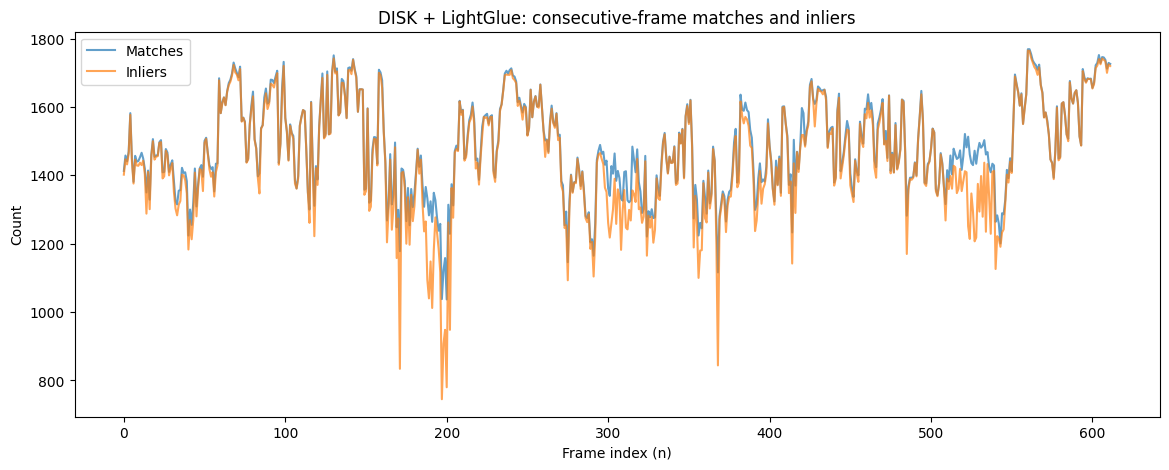

In [6]:
import matplotlib.pyplot as plt
from IPython.display import Image

plt.figure(figsize=(14, 5))
plt.plot(df_disk["Frame_n"], df_disk["Matches"], label="Matches", alpha=0.7)
plt.plot(df_disk["Frame_n"], df_disk["Inliers"], label="Inliers", alpha=0.7)
plt.xlabel("Frame index (n)")
plt.ylabel("Count")
plt.title("DISK + LightGlue: consecutive-frame matches and inliers")
plt.legend()
plt.savefig("/content/disk_plot.png", dpi=100, bbox_inches='tight')
plt.close()

Image("/content/disk_plot.png")

In [7]:
disk_counts = []
for i in range(0, len(image_files), 10):
    img_bgr = cv2.imread(image_files[i])
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    t = K.image_to_tensor(img_rgb, False).float().to(device) / 255.0
    with torch.no_grad():
        feats = disk(t, n=2048, window_size=5, score_threshold=0.0, pad_if_not_divisible=True)[0]
    disk_counts.append(len(feats.keypoints))

print("Avg DISK keypoints (sampled):", sum(disk_counts)/len(disk_counts))

/tmp/ipykernel_5719/2152271538.py:5: DeprecationWarning: Since kornia 0.8.3 the `image_to_tensor` is deprecated in favor of `kornia.image.image_to_tensor`.
  t = K.image_to_tensor(img_rgb, False).float().to(device) / 255.0
/tmp/ipykernel_5719/2152271538.py:5: DeprecationWarning: Since kornia 0.8.3 the `image_to_tensor` is deprecated in favor of `kornia.image.image_to_tensor`.
  t = K.image_to_tensor(img_rgb, False).float().to(device) / 255.0
/tmp/ipykernel_5719/2152271538.py:5: DeprecationWarning: Since kornia 0.8.3 the `image_to_tensor` is deprecated in favor of `kornia.image.image_to_tensor`.
  t = K.image_to_tensor(img_rgb, False).float().to(device) / 255.0
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipyke

Avg DISK keypoints (sampled): 2041.4516129032259


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipykernel_5719/2152271538.py:5: DeprecationWarning: Since kornia 0.8.3 the `image_to_tensor` is deprecated in favor of `kornia.image.image_to_tensor`.
  t = K.image_to_tensor(img_rgb, False).float().to(device) / 255.0
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [12]:
# Create DataFrame
df_disk = pd.DataFrame(
    results_disk,
    columns=["Frame_n", "Frame_n+1", "Matches", "Inliers"]
)

# Calculate Inlier Ratio
df_disk["Inlier_Ratio"] = (
    df_disk["Inliers"] /
    df_disk["Matches"].replace(0, pd.NA)
)

# Display first 10 rows
print(df_disk.head(10))

# Display statistics
print("\nSummary Statistics")
print("------------------")
print("Total Rows          :", len(df_disk))
print("Average Matches     :", df_disk["Matches"].mean())
print("Average Inliers     :", df_disk["Inliers"].mean())
print("Average Inlier Ratio:", df_disk["Inlier_Ratio"].mean())

# Save DataFrame to Google Drive
output_path = "/content/drive/MyDrive/disk_lightglue_consecutive_pairs.csv"
df_disk.to_csv(output_path, index=False)

print(f"\nSaved {len(df_disk)} rows to:")
print(output_path)

   Frame_n  Frame_n+1  Matches  Inliers  Inlier_Ratio
0        0          1     1413     1402      0.992215
1        1          2     1458     1447      0.992455
2        2          3     1441     1432      0.993754
3        3          4     1470     1464      0.995918
4        4          5     1582     1577      0.996839
5        5          6     1450     1441      0.993793
6        6          7     1381     1376      0.996379
7        7          8     1457     1446      0.992450
8        8          9     1440     1429      0.992361
9        9         10     1442     1428      0.990291

Summary Statistics
------------------
Total Rows          : 612
Average Matches     : 1482.673202614379
Average Inliers     : 1456.1552287581699
Average Inlier Ratio: 0.9805349134880053

Saved 612 rows to:
/content/drive/MyDrive/disk_lightglue_consecutive_pairs.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
